In [1]:
%pip install statsmodels seaborn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: C:\Users\Olivia\AppData\Local\Programs\Python\Python313\python.exe -m pip install --upgrade pip


In [2]:
import numpy as np
import pandas as pd
import statsmodels
import statsmodels.api as sm
from statsmodels.tsa.stattools import coint, adfuller

import matplotlib.pyplot as plt
import seaborn as sns; sns.set(style="whitegrid")

import yfinance as yf

In [3]:
import datetime

# Major US money-center / regional banks: same sector, driven by shared
# macro factors (rate cycle, credit conditions), so more likely to exhibit
# genuine cointegration than an arbitrary cross-sector basket.
tickers = ['JPM', 'BAC', 'WFC', 'C', 'GS', 'MS', 'USB', 'PNC', 'TFC', 'COF']

start = datetime.datetime(2020, 1, 1)
end = datetime.datetime(2025, 12, 31)

data = yf.download(tickers, start=start, end=end)["Close"]
data = data.dropna(axis=1, how="all")  # drop tickers that failed to download entirely
data = data.dropna()

dropped = sorted(set(tickers) - set(data.columns))
if dropped:
    print(f"Dropped tickers with no data: {dropped}")
tickers = list(data.columns)  # keep tickers in sync with what actually downloaded

data.tail()

[                       0%                       ]

[**********            20%                       ]  2 of 10 completed

[**********            20%                       ]  2 of 10 completed

[*******************   40%                       ]  4 of 10 completed

[**********************50%                       ]  5 of 10 completed

[**********************70%*********              ]  7 of 10 completed

[**********************90%******************     ]  9 of 10 completed

[*********************100%***********************]  10 of 10 completed

Ticker,BAC,C,COF,GS,JPM,MS,PNC,TFC,USB,WFC
Date,,,,,,,,,,
2025-12-23,55.367695,118.221634,245.601974,893.053589,322.814331,177.561676,208.732071,49.463211,52.963444,93.473564
2025-12-24,55.644680,120.360313,246.266556,902.036438,326.023376,179.688461,210.238846,49.708126,53.400833,94.294807
2025-12-26,55.565540,119.231567,247.308090,898.332275,324.775421,179.906097,210.642624,49.580769,53.449436,94.255234
2025-12-29,54.754364,116.964165,243.766891,883.614990,320.655182,177.996933,208.751770,49.002769,52.973160,93.523026
2025-12-30,54.685120,116.053246,242.001266,875.929443,320.328339,177.146225,207.855591,48.552124,52.788486,93.315247


In [4]:
# Chronological train/test split, done BEFORE any pair discovery or model
# fitting. Cointegration scanning and hedge-ratio estimation below only
# ever see train_data, so the test period stays genuinely out-of-sample.
split = int(len(data) * 0.70)
train_data = data.iloc[:split]
test_data = data.iloc[split:]

print(f"Train: {train_data.index[0].date()} to {train_data.index[-1].date()} ({len(train_data)} days)")
print(f"Test:  {test_data.index[0].date()} to {test_data.index[-1].date()} ({len(test_data)} days)")


Train: 2020-01-02 to 2024-03-11 (1054 days)
Test:  2024-03-12 to 2025-12-30 (453 days)


In [5]:
""" Data science in trading """
# function to find cointegrated security pairs
def find_cointegrated_pairs(data):
    n = data.shape[1]
    score_matrix = np.zeros((n, n))
    pvalue_matrix = np.ones((n, n))
    keys = data.keys()
    pairs = []
    for i in range(n):
        for j in range(i+1, n):
            S1 = data[keys[i]]
            S2 = data[keys[j]]
            result = coint(S1, S2)
            score = result[0]
            pvalue = result[1]
            score_matrix[i, j] = score
            pvalue_matrix[i, j] = pvalue
            if pvalue < 0.05:
                pairs.append((keys[i], keys[j]))
    return score_matrix, pvalue_matrix, pairs

Cointegrated pairs on training data (p < 0.05):
BAC - PNC
C - COF
GS - WFC
MS - WFC
PNC - USB


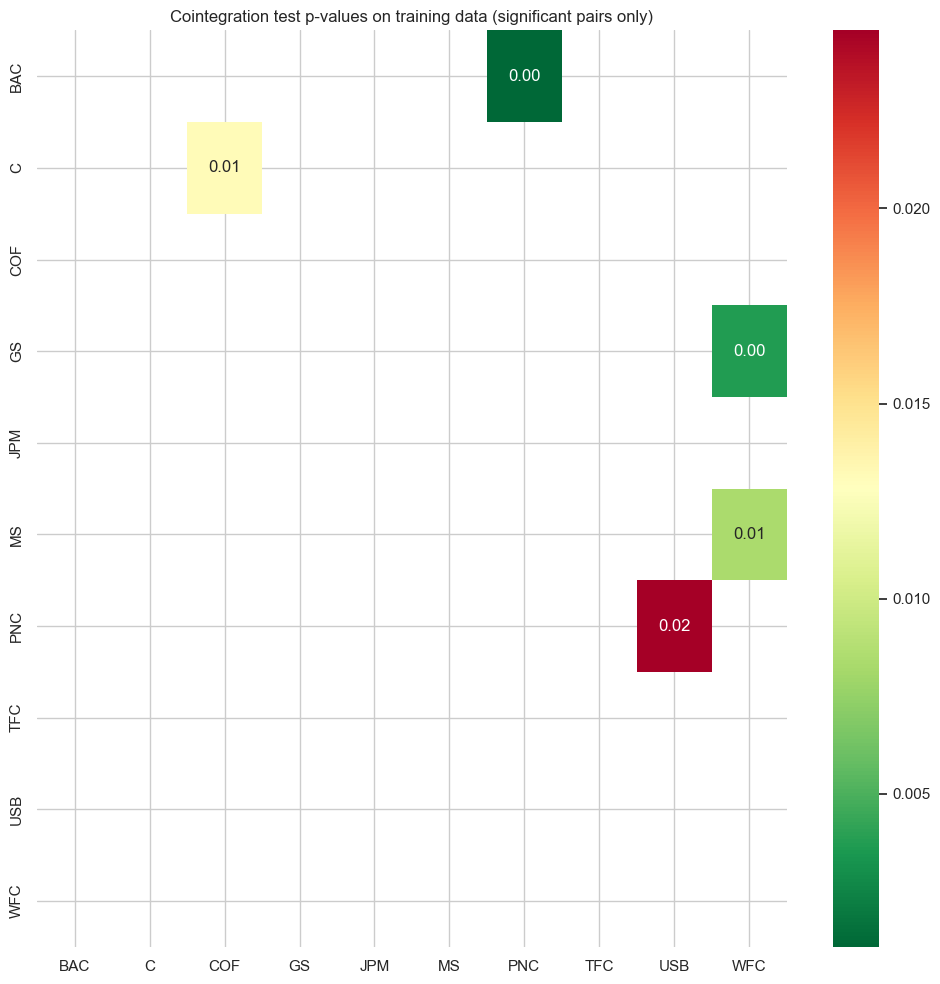

In [6]:
# Heatmap to show the p-values of the cointegration test between each pair of
# stocks, computed on the TRAINING data only so pair selection can't peek at
# the test period. Only show the value in the upper-diagonal of the heatmap.
score_matrix, pvalue_matrix, pairs = find_cointegrated_pairs(train_data)

fig, ax = plt.subplots(figsize=(10, 10))
sns.heatmap(pvalue_matrix, xticklabels=tickers, yticklabels=tickers, cmap='RdYlGn_r',
            mask=(pvalue_matrix >= 0.05), annot=True, fmt=".2f")
plt.title("Cointegration test p-values on training data (significant pairs only)")
plt.tight_layout()

print("Cointegrated pairs on training data (p < 0.05):")
for t1, t2 in pairs:
    print(f"{t1} - {t2}")

Candidates ranked by cointegration p-value on a held-out slice of
training data (fit = first 80% of train, val = last 20% of train):
  C - COF: fit_p=0.0199  val_p=0.0066 <- robust on both train sub-periods

Using pair: C / COF
Cointegration test p-value (train, full): 0.0132
Cointegration test p-value (test, out-of-sample check): 0.8766
Spread ADF test p-value (train): 0.0026


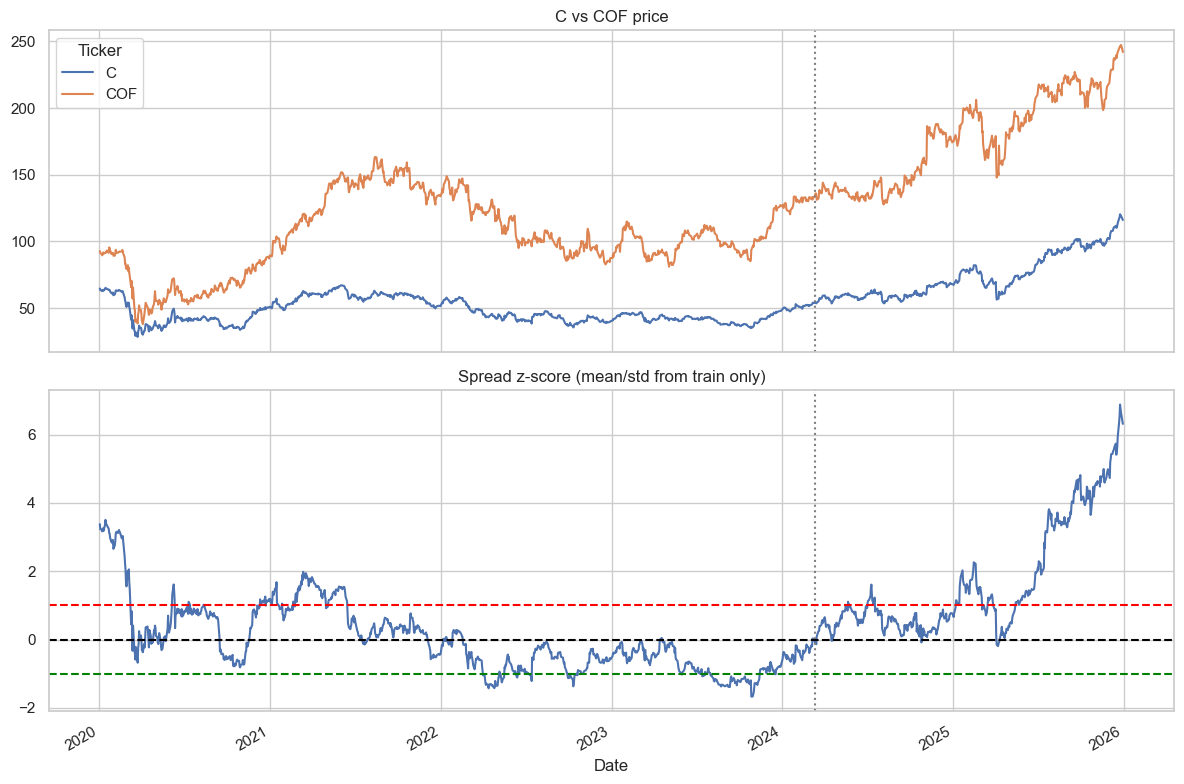

In [7]:
# Select the pair among the training-cointegrated candidates that is most
# robust, using a validation slice carved out of TRAINING data only (last
# 20% of train_data). Ranking candidates by their p-value on test_data
# directly would leak the test period into pair selection and defeat the
# point of the train/test split above -- so test_data stays untouched
# until the out-of-sample check further down.
if pairs:
    val_split = int(len(train_data) * 0.8)
    train_fit, train_val = train_data.iloc[:val_split], train_data.iloc[val_split:]

    candidates = []
    for t1, t2 in pairs:
        fit_pvalue = coint(train_fit[t1], train_fit[t2])[1]
        val_pvalue = coint(train_val[t1], train_val[t2])[1]
        candidates.append((t1, t2, fit_pvalue, val_pvalue))

    # Prefer pairs cointegrated on BOTH training sub-periods (robust to
    # where the split falls), falling back to the lowest validation
    # p-value if no candidate clears that bar on both.
    robust = [c for c in candidates if c[2] < 0.05 and c[3] < 0.05]
    ranked = sorted(robust or candidates, key=lambda c: c[3])
    robust_keys = {(t1, t2) for t1, t2, _, _ in robust}

    print("Candidates ranked by cointegration p-value on a held-out slice of")
    print("training data (fit = first 80% of train, val = last 20% of train):")
    for t1, t2, fit_p, val_p in ranked:
        flag = " <- robust on both train sub-periods" if (t1, t2) in robust_keys else ""
        print(f"  {t1} - {t2}: fit_p={fit_p:.4f}  val_p={val_p:.4f}{flag}")

    TICKER_1, TICKER_2 = ranked[0][0], ranked[0][1]
else:
    TICKER_1, TICKER_2 = tickers[0], tickers[1]

print(f"\nUsing pair: {TICKER_1} / {TICKER_2}")

score, pvalue, _ = coint(train_data[TICKER_1], train_data[TICKER_2])
print(f"Cointegration test p-value (train, full): {pvalue:.4f}")

test_pvalue = coint(test_data[TICKER_1], test_data[TICKER_2])[1]
print(f"Cointegration test p-value (test, out-of-sample check): {test_pvalue:.4f}")

# Hedge ratio via OLS fit on the training data only, then applied to the
# full series so we can see how the spread behaves out-of-sample too
hedge_ratio = sm.OLS(train_data[TICKER_1], sm.add_constant(train_data[TICKER_2])).fit().params[TICKER_2]
spread = data[TICKER_1] - hedge_ratio * data[TICKER_2]
spread_train = spread.iloc[:split]

adf_pvalue = adfuller(spread_train)[1]
print(f"Spread ADF test p-value (train): {adf_pvalue:.4f}")

# z-score uses only the train mean/std, so the test-period values are a
# genuine out-of-sample view rather than being normalized against themselves
zscore = (spread - spread_train.mean()) / spread_train.std()

fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)
data[[TICKER_1, TICKER_2]].plot(ax=axes[0], title=f"{TICKER_1} vs {TICKER_2} price")
zscore.plot(ax=axes[1], title="Spread z-score (mean/std from train only)")
for ax in axes:
    ax.axvline(data.index[split], color="grey", linestyle=":")
axes[1].axhline(0, color="black", linestyle="--")
axes[1].axhline(1, color="red", linestyle="--")
axes[1].axhline(-1, color="green", linestyle="--")
plt.tight_layout()

In [8]:
ratios = data[TICKER_1] / data[TICKER_2]
train = ratios.iloc[:split]
test = ratios.iloc[split:]

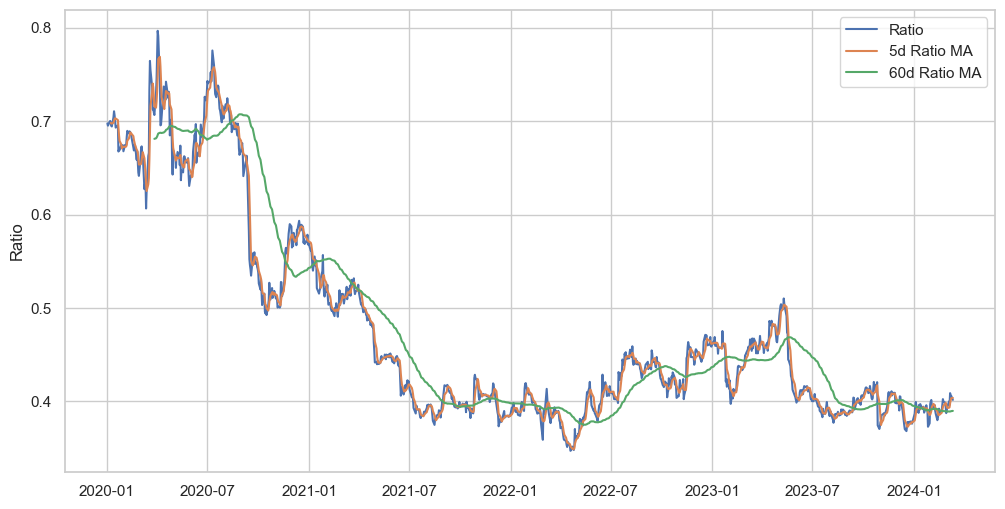

In [9]:
""" Feature engineering 
    - 60 day moving average of ratio
    - 5 day moving average of ratio
    - 60 day standard deviation
    - z score
"""

ratios_mavg5 = train.rolling(window=5, center=False).mean()
ratios_mavg60 = train.rolling(window=60, center=False).mean()
std_60 = train.rolling(window=60, center=False).std()
zscore_60_5 = (ratios_mavg5 - ratios_mavg60)/std_60
plt.figure(figsize=(12, 6))
plt.plot(train.index, train.values)
plt.plot(ratios_mavg5.index, ratios_mavg5.values)
plt.plot(ratios_mavg60.index, ratios_mavg60.values)
plt.legend(['Ratio', '5d Ratio MA', '60d Ratio MA'])

plt.ylabel('Ratio')
plt.show()

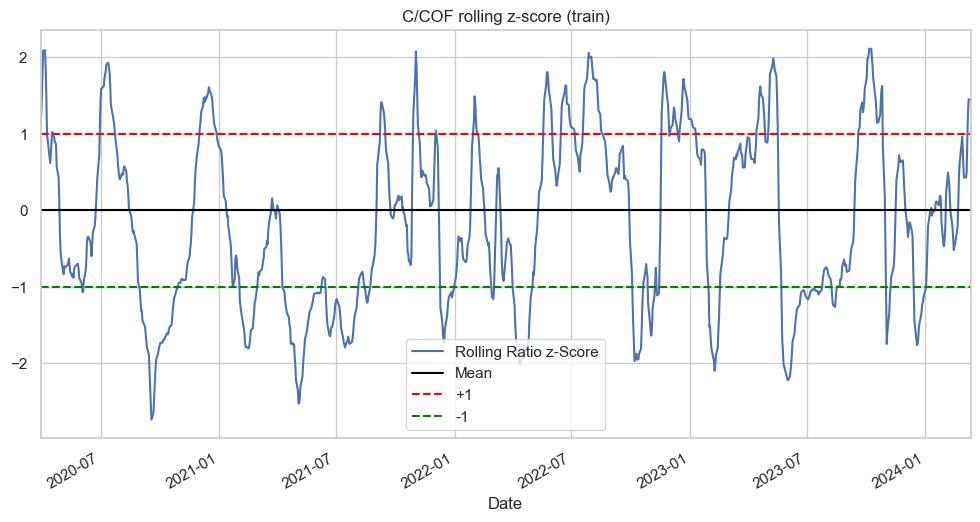

In [10]:
plt.figure(figsize=(12,6))
zscore_60_5.plot()
plt.xlim(train.index[60], train.index[-1])
plt.axhline(0, color='black')
plt.axhline(1.0, color='red', linestyle='--')
plt.axhline(-1.0, color='green', linestyle='--')
plt.legend(['Rolling Ratio z-Score', 'Mean', '+1', '-1'])
plt.title(f"{TICKER_1}/{TICKER_2} rolling z-score (train)")
plt.show()

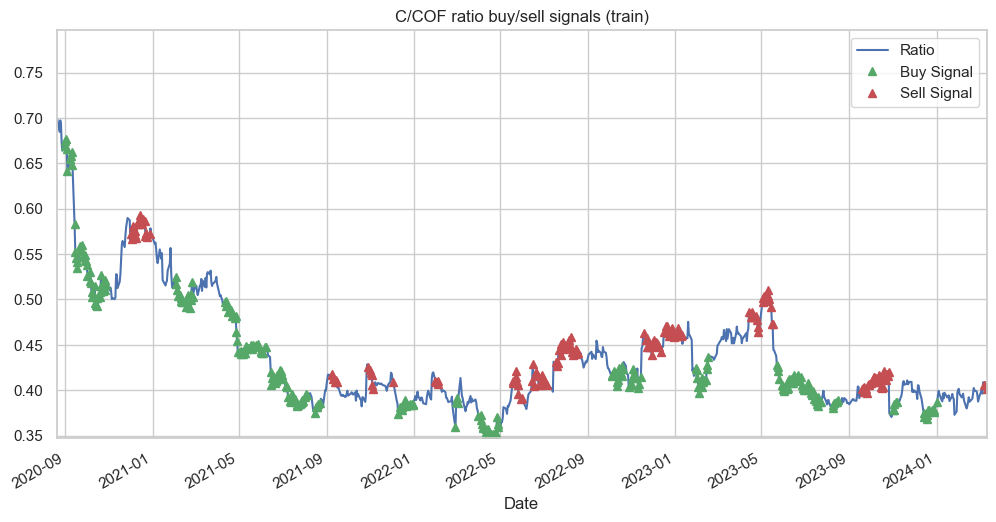

In [11]:
"""
Creating a model
Buy(1) whenever z-score below -1 - expect ratio to increase
Sell(-1) whenever z-score above 1 - expect ratio to decrease
"""

# Training optimizing
plt.figure(figsize=(12, 6))

train[160:].plot()
buy = train.copy()
sell = train.copy()
buy[zscore_60_5>-1] = 0
sell[zscore_60_5<1] = 0
buy[160:].plot(color='g', linestyle='None', marker='^')
sell[160:].plot(color='r', linestyle='None', marker='^')
x1, x2, y1, y2 = plt.axis()
plt.axis((x1, x2, ratios.min(), ratios.max()))
plt.xlim(train.index[160], train.index[-1])
plt.legend(['Ratio', 'Buy Signal', 'Sell Signal'])
plt.title(f"{TICKER_1}/{TICKER_2} ratio buy/sell signals (train)")
plt.show()

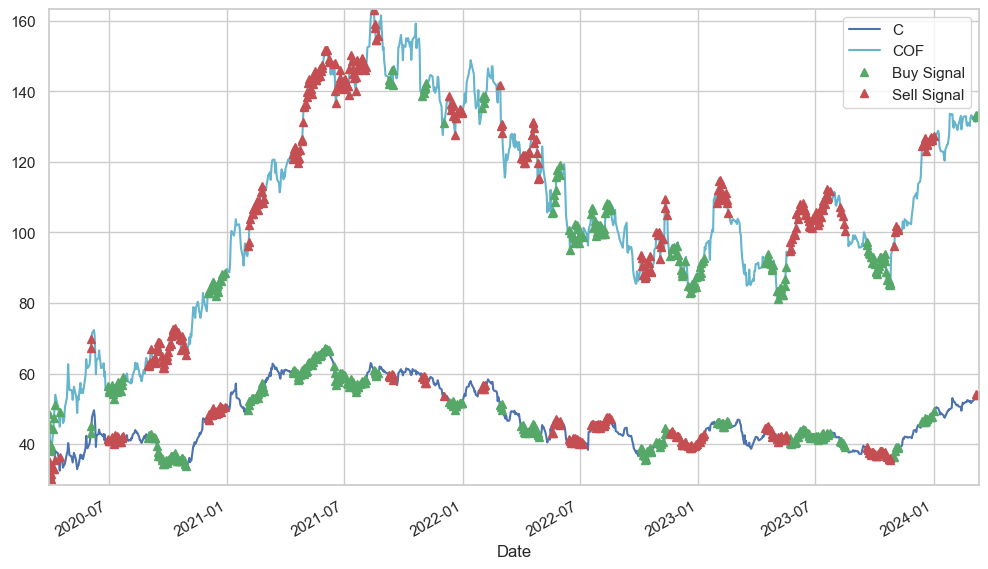

In [12]:
plt.figure(figsize=(12,7))
S1 = data[TICKER_1].iloc[:split]
S2 = data[TICKER_2].iloc[:split]

S1[60:].plot(color='b')
S2[60:].plot(color='c')
buyR = 0*S1.copy()
sellR = 0*S1.copy()

# When you buy the ratio, you buy stock S1 and sell S2
buyR[buy!=0] = S1[buy!=0]
sellR[buy!=0] = S2[buy!=0]

# When you sell the ratio, you sell stock S1 and buy S2
buyR[sell!=0] = S2[sell!=0]
sellR[sell!=0] = S1[sell!=0]

buyR[60:].plot(color='g', linestyle='None', marker='^')
sellR[60:].plot(color='r', linestyle='None', marker='^')
x1, x2, y1, y2 = plt.axis()
plt.axis((x1, x2, min(S1.min(), S2.min()), max(S1.max(), S2.max())))
plt.xlim(train.index[60], train.index[-1])

plt.legend([TICKER_1, TICKER_2, 'Buy Signal', 'Sell Signal'])
plt.show()

In [13]:
# Trade using a simple z-score strategy
def trade(S1, S2, window_fast, window_slow, entry_z=1.0, exit_z=0.75, verbose=False):
    """Backtest a rolling z-score pairs strategy on S1/S2.

    Enters a self-financed long/short spread position (long 1 share of S1,
    short `ratio` shares of S2, or vice versa) when the z-score crosses
    entry_z, holds at most one unit of the spread at a time, and exits when
    the z-score reverts inside exit_z. Marks the position to market every
    day, so any position still open at the end of the series is reflected
    in the final equity value.
    """
    if window_fast == 0 or window_slow == 0:
        raise ValueError("window_fast and window_slow must be non-zero")

    ratios = S1 / S2
    ma_fast = ratios.rolling(window=window_fast, center=False).mean()
    ma_slow = ratios.rolling(window=window_slow, center=False).mean()
    std_slow = ratios.rolling(window=window_slow, center=False).std()
    zscore = (ma_fast - ma_slow) / std_slow

    cash = 0.0
    count_s1 = 0.0
    count_s2 = 0.0
    position_s1, position_s2, equity = [], [], []

    for i in range(len(ratios)):
        price1, price2, z, r = S1.iloc[i], S2.iloc[i], zscore.iloc[i], ratios.iloc[i]

        if pd.notna(z):
            if z < -entry_z and count_s1 == 0:
                # Ratio is low: long S1, short r*S2 (self-financed hedge)
                count_s1 += 1
                count_s2 -= r
                if verbose:
                    print(f"{ratios.index[i].date()} LONG spread  z={z:.2f}")
            elif z > entry_z and count_s1 == 0:
                # Ratio is high: short S1, long r*S2
                count_s1 -= 1
                count_s2 += r
                if verbose:
                    print(f"{ratios.index[i].date()} SHORT spread z={z:.2f}")
            elif abs(z) < exit_z and count_s1 != 0:
                cash += count_s1 * price1 + count_s2 * price2
                count_s1 = 0.0
                count_s2 = 0.0
                if verbose:
                    print(f"{ratios.index[i].date()} EXIT         z={z:.2f}")

        position_s1.append(count_s1)
        position_s2.append(count_s2)
        equity.append(cash + count_s1 * price1 + count_s2 * price2)

    return pd.DataFrame(
        {
            "zscore": zscore.values,
            "position_S1": position_s1,
            "position_S2": position_s2,
            "equity": equity,
        },
        index=ratios.index,
    )


Total P&L: $14.71
Number of trades (entries + exits): 27
Annualized Sharpe (on daily $ P&L): 0.64
Max drawdown: $-8.29


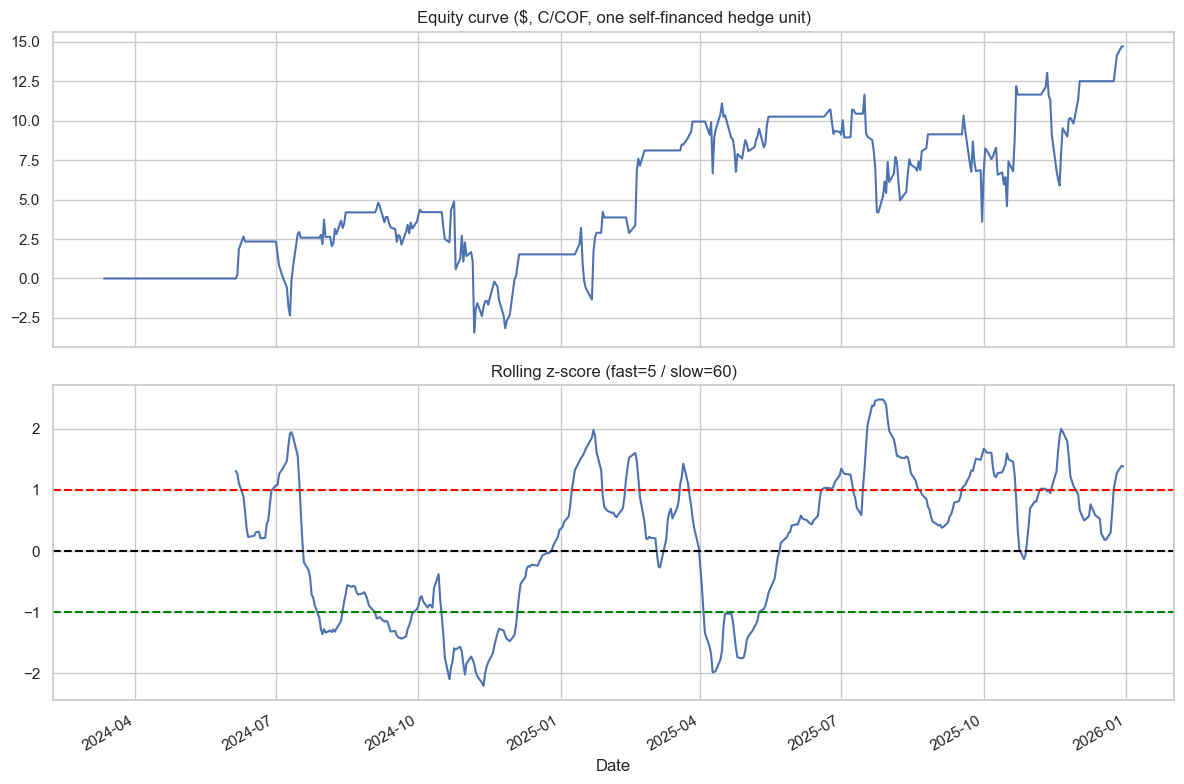

In [14]:
# window_fast=5, window_slow=60 matches the zscore_60_5 convention used above
# (fast MA minus slow MA, divided by std over the slow window)
result = trade(data[TICKER_1].iloc[split:], data[TICKER_2].iloc[split:], window_fast=5, window_slow=60)

equity = result["equity"]
daily_pnl = equity.diff().fillna(0.0)
n_trades = (result["position_S1"].diff().fillna(0) != 0).sum()
sharpe = daily_pnl.mean() / daily_pnl.std() * np.sqrt(252) if daily_pnl.std() else float("nan")
running_max = equity.cummax()
max_drawdown = (equity - running_max).min()

print(f"Total P&L: ${equity.iloc[-1]:,.2f}")
print(f"Number of trades (entries + exits): {n_trades}")
print(f"Annualized Sharpe (on daily $ P&L): {sharpe:.2f}")
print(f"Max drawdown: ${max_drawdown:,.2f}")

fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)
equity.plot(ax=axes[0], title=f"Equity curve ($, {TICKER_1}/{TICKER_2}, one self-financed hedge unit)")
result["zscore"].plot(ax=axes[1], title="Rolling z-score (fast=5 / slow=60)")
axes[1].axhline(1, color="red", linestyle="--")
axes[1].axhline(-1, color="green", linestyle="--")
axes[1].axhline(0, color="black", linestyle="--")
plt.tight_layout()
plt.show()